In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

(853, 1280, 3)
uint8


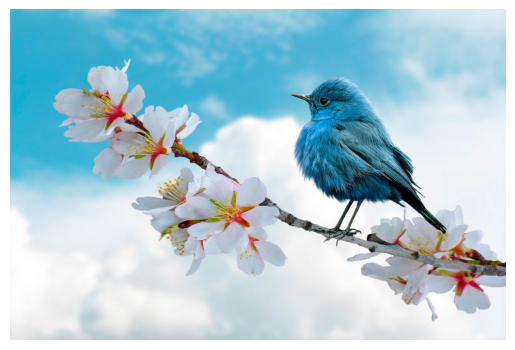

In [7]:
img = Image.open('/Users/gokulbj/Downloads/elg21-bird-8788491_1280.jpg')

img_array = np.array(img)

print(img_array.shape) 
print(img_array.dtype)

plt.imshow(img_array)
plt.axis('off')
plt.show() 

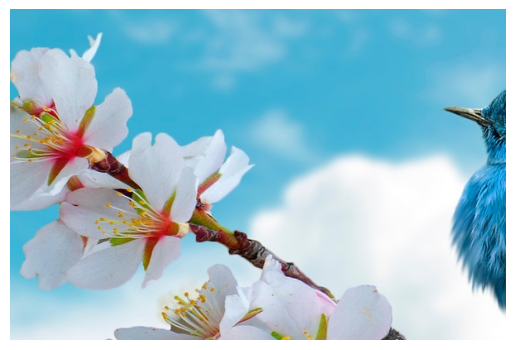

In [13]:

plt.imshow(img_array[100:500, 200:800])
plt.axis('off')
plt.show() 

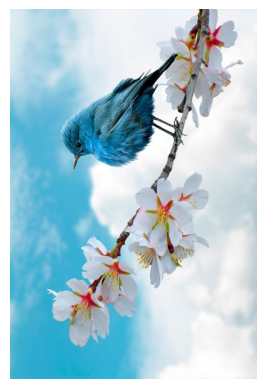

In [ ]:
plt.imshow(np.rot90(img_array))
plt.axis('off')
plt.show() 

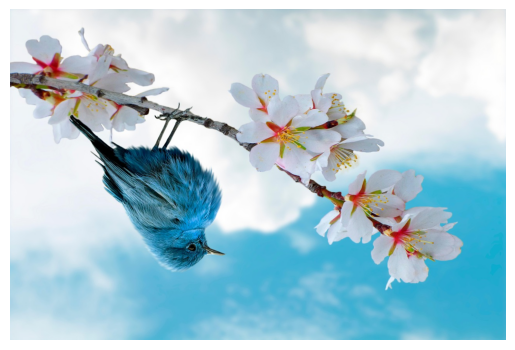

In [16]:
plt.imshow(np.rot90(img_array, k=2))
plt.axis('off')
plt.show() 

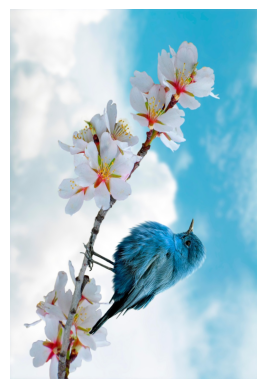

In [17]:
plt.imshow(np.rot90(img_array, k=3))
plt.axis('off')
plt.show() 

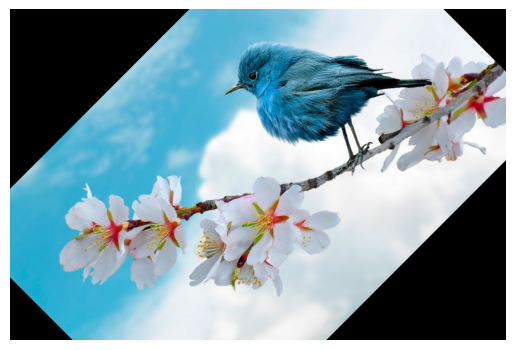

In [18]:
plt.imshow(img.rotate(45))
plt.axis('off')
plt.show() 

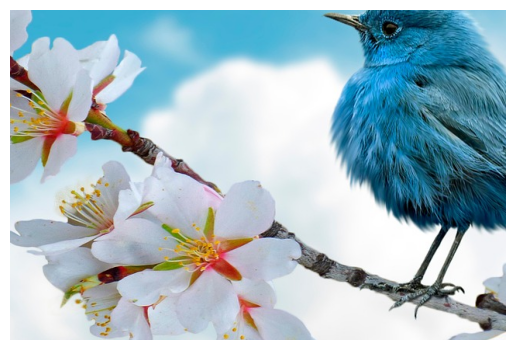

In [23]:
h, w, _ = img_array.shape

center_crop = img_array[
    h//4:3*h//4,
    w//4:3*w//4
]

plt.imshow(center_crop)
plt.axis('off')
plt.show()

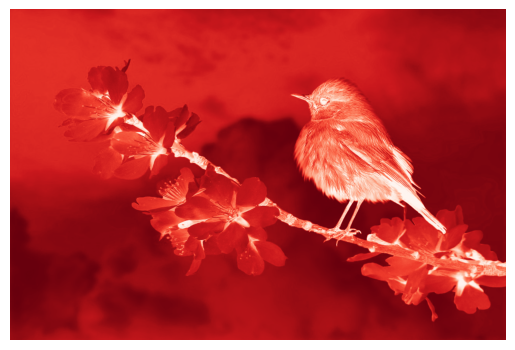

In [ ]:
plt.imshow(img_array[:,:,0], cmap='Reds')
plt.axis('off')
plt.show() 

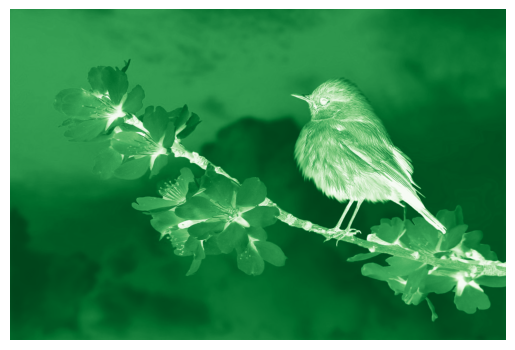

In [44]:
plt.imshow(img_array[:,:,1], cmap='Greens')
plt.axis('off')
plt.show() 

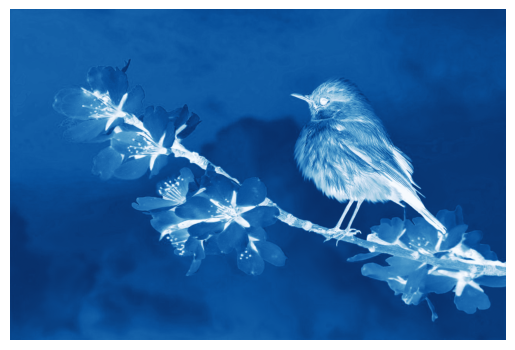

In [42]:
plt.imshow(img_array[:,:,2], cmap='Blues')
plt.axis('off')
plt.show() 

(853, 1280, 3)


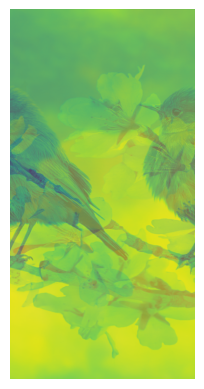

In [49]:
print(img_array.shape)
plt.imshow(img_array.reshape(-1, img_array.shape[1]))
plt.axis('off')
plt.show() 

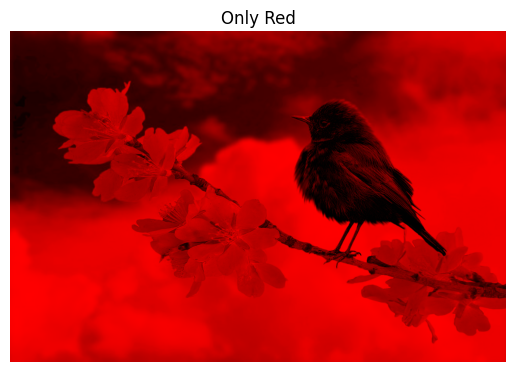

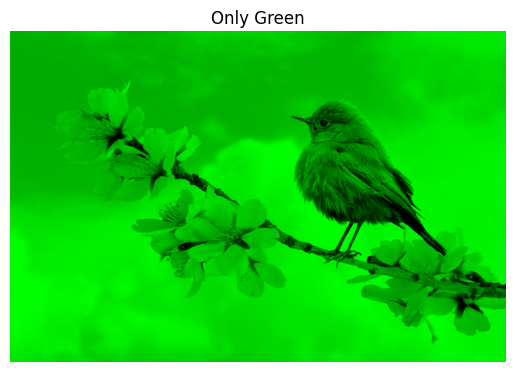

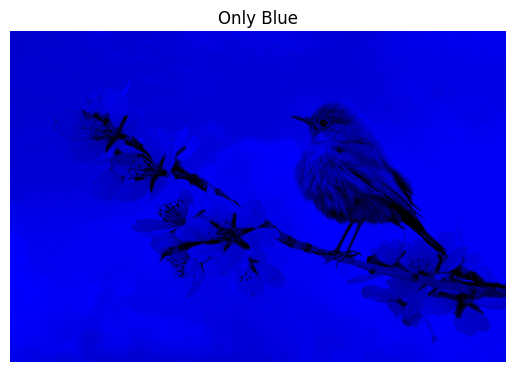

In [47]:
red = img_array.copy()
red[:, :, 1] = 0
red[:, :, 2] = 0

green = img_array.copy()
green[:, :, 0] = 0
green[:, :, 2] = 0

blue = img_array.copy()
blue[:, :, 0] = 0
blue[:, :, 1] = 0

plt.imshow(red)
plt.title("Only Red")
plt.axis('off')
plt.show()

plt.imshow(green)
plt.title("Only Green")
plt.axis('off')
plt.show()

plt.imshow(blue)
plt.title("Only Blue")
plt.axis('off')
plt.show()

In [52]:
import numpy as np

array = np.linspace(10, 20, num=4)

print(array)


[10.         13.33333333 16.66666667 20.        ]


In [157]:
def magnify_repeated(image, factor):
    h, w = image.shape
    magnified_image = np.zeros((h * factor, w * factor), dtype=image.dtype)
    
    for i in range(h):
        for j in range(w):
            magnified_image[i*factor:(i+1)*factor, j*factor:(j+1)*factor] = image[i, j]
    
    return magnified_image

In [158]:
print(magnify_repeated(np.array([[1, 2], [3, 4]]), 4))

[[1 1 1 1 2 2 2 2]
 [1 1 1 1 2 2 2 2]
 [1 1 1 1 2 2 2 2]
 [1 1 1 1 2 2 2 2]
 [3 3 3 3 4 4 4 4]
 [3 3 3 3 4 4 4 4]
 [3 3 3 3 4 4 4 4]
 [3 3 3 3 4 4 4 4]]


In [153]:
def magnify(image, factor):
    h, w = image.shape
    magnified_image = np.zeros(((h - 1) * factor, (w - 1) * factor), dtype=float)
    
    for i in range(h-1):
        for j in range(w-1):
            temp1 = np.linspace(image[i, j], image[i, j+1], num=factor)
            temp2 = np.linspace(image[i + 1, j], image[i+1, j + 1], num=factor)
            
            print("temp1: ", temp1)
            print("temp2: ", temp2)

            for r in range(factor):
                for c in range(factor):
                    top_val = temp1[c]
                    bottom_val = temp2[c]

                    value = np.linspace(top_val, bottom_val, num=factor)
                    print("value: ", value)
                    print(f"Setting magnified_image[{i * factor + r}, {j * factor + c}] to {value[r]}")
                    magnified_image[i * factor + r, j * factor + c] = value[r]

    return magnified_image

In [154]:
print(magnify(np.array([[1, 2], [3, 4]]), 4))

temp1:  [1.         1.33333333 1.66666667 2.        ]
temp2:  [3.         3.33333333 3.66666667 4.        ]
value:  [1.         1.66666667 2.33333333 3.        ]
Setting magnified_image[0, 0] to 1.0
value:  [1.33333333 2.         2.66666667 3.33333333]
Setting magnified_image[0, 1] to 1.3333333333333333
value:  [1.66666667 2.33333333 3.         3.66666667]
Setting magnified_image[0, 2] to 1.6666666666666665
value:  [2.         2.66666667 3.33333333 4.        ]
Setting magnified_image[0, 3] to 2.0
value:  [1.         1.66666667 2.33333333 3.        ]
Setting magnified_image[1, 0] to 1.6666666666666665
value:  [1.33333333 2.         2.66666667 3.33333333]
Setting magnified_image[1, 1] to 2.0
value:  [1.66666667 2.33333333 3.         3.66666667]
Setting magnified_image[1, 2] to 2.333333333333333
value:  [2.         2.66666667 3.33333333 4.        ]
Setting magnified_image[1, 3] to 2.6666666666666665
value:  [1.         1.66666667 2.33333333 3.        ]
Setting magnified_image[2, 0] to 2.3

In [ ]:
def reduce_size(image, height_win, width_win,strides, padding):
    h, w = image.shape

    pad_h = height_win // 2
    pad_w = width_win // 2
    if padding:
        image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    h, w = image.shape

    reduced_image = np.zeros(((image.shape[0] - height_win) // strides + 1, (image.shape[1] - width_win) // strides + 1), dtype=float)
    
    for i in range(0, h - height_win + 1, strides):
        for j in range(0, w - width_win + 1, strides):
            block = image[i:i+height_win, j:j+width_win]
            reduced_value = np.mean(block)
            reduced_image[i // strides, j // strides] = reduced_value
    print(image)
    return reduced_image

In [190]:
print(reduce_size(np.array([[1, 2], [3, 4]]), 2, 2, 2, True))

[[0 0 0 0]
 [0 1 2 0]
 [0 3 4 0]
 [0 0 0 0]]
[[0.25 0.5 ]
 [0.75 1.  ]]
